<a href="https://colab.research.google.com/github/thaiyalvishu97/MyProjects/blob/main/Project_18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("ScreenTime vs MentalWellness.csv")

In [4]:
df.isnull().sum()

,0
user_id,0
age,0
gender,0
occupation,0
work_mode,0
screen_time_hours,0
work_screen_hours,0
leisure_screen_hours,0
sleep_hours,0
sleep_quality_1_5,0


In [7]:
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])
df['occupation'] = le.fit_transform(df['occupation'])
df['work_mode'] = le.fit_transform(df['work_mode'])

In [8]:
df

,user_id,age,gender,occupation,work_mode,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,exercise_minutes_per_week,social_hours_per_week,mental_wellness_index_0_100,Unnamed: 15
0,U0001,33,0,0,2,10.79,5.44,5.35,6.63,1,9.3,44.7,127,0.7,9.3,NaN
1,U0002,28,0,0,1,7.40,0.37,7.03,8.05,3,5.7,78.0,74,2.1,56.2,NaN
2,U0003,35,0,0,0,9.78,1.09,8.69,6.48,1,9.1,51.8,67,8.0,3.6,NaN
3,U0004,42,1,0,0,11.13,0.56,10.57,6.89,1,10.0,37.0,0,5.7,0.0,NaN
4,U0005,28,1,3,2,13.22,4.09,9.13,5.79,1,10.0,38.5,143,10.1,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,U0396,26,0,3,2,6.43,2.99,3.44,7.75,1,5.9,64.6,252,7.6,39.3,NaN
396,U0397,16,1,2,2,9.59,5.44,4.15,5.57,1,10.0,47.4,99,7.0,3.5,NaN
397,U0398,40,1,3,2,8.72,2.36,6.36,7.56,1,9.4,57.3,193,10.1,6.6,NaN
398,U0399,29,0,1,0,5.04,0.94,4.10,7.32,1,7.1,63.6,97,12.1,21.0,NaN


In [9]:
X = df.iloc[:,1:15]
from sklearn.decomposition import PCA
pca = PCA(n_components=2,random_state=42)
X_pca = pca.fit_transform(X)

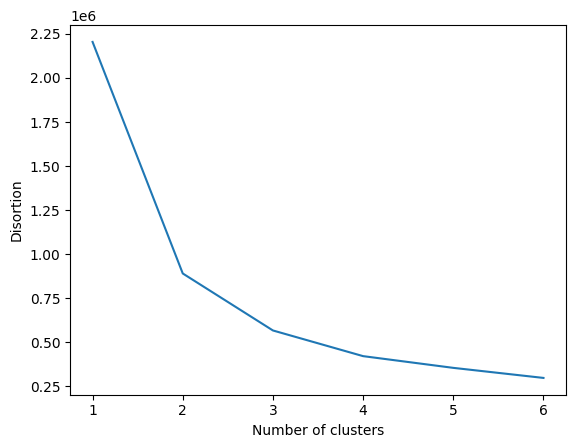

In [13]:
disortion = []
for i in range(1,7):
  model = KMeans(n_clusters=i,init='k-means++',n_init=10,random_state=42)
  model.fit(X_pca)
  disortion.append(model.inertia_)
plt.plot(range(1,7),disortion)
plt.xlabel('Number of clusters')
plt.ylabel('Disortion')
plt.show()

In [31]:
model = KMeans(n_clusters=3,random_state=42,init='k-means++',n_init=10)

In [32]:
model.fit(X_pca)

KMeans(n_clusters=3, n_init=10, random_state=42)

In [33]:
y = model.predict(X_pca)

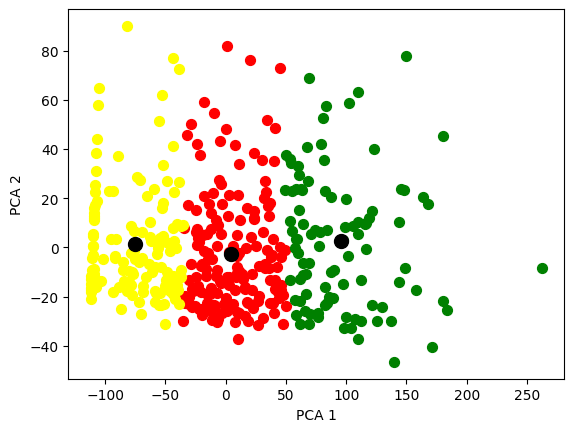

In [35]:
plt.scatter(X_pca[y==0,0],X_pca[y==0,1],s=50,c='red',label='Cluster 1')
plt.scatter(X_pca[y==1,0],X_pca[y==1,1],s=50,c='green',label='Cluster 2')
plt.scatter(X_pca[y==2,0],X_pca[y==2,1],s=50,c='yellow',label='Cluster 3')
plt.scatter(model.cluster_centers_[:,0],model.cluster_centers_[:,1],s=100,c='black',label='Centroids')
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()